---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 32 / 32 — Bloque IV

**Nivel GCE:** Síntesis GCE — tabla de los 7 Pilares de Pearl (Sec. 5b) y cierre de la cadena maestra |ATE| ≤ W1 con el experimento canónico del Cap. 1, semilla 42 (Sec. 7)

**Dataset:** `syn_roadmap`

**Versión:** 2.2 (bug sistémico de etiquetado GCE corregido — auditoría 2026-07-30)

**Fecha:** 2026-07-30

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 32: Hoja de Ruta de la IA Causal y Problemas Abiertos

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 32 / 32 — Bloque IV (capítulo final)

---

## 1. Marco Teórico

### 1.1 Recapitulación: los 32 capítulos

Hemos recorrido un largo camino:
- **Bloque I (Caps. 1-12):** Fundamentación. RCT, matching, IPW, IV, RDD, DiD, SCM, mediación, robustez.
- **Bloque II (Caps. 13-19):** Formalización. SCM, DAGs, backdoor, frontdoor, do-calculus, contrafactuales.
- **Bloque III (Caps. 20-27):** Descubrimiento y heterogeneidad. PC algorithm, Meta-Learners, DML, Causal Forests, OPE, CFR.
- **Bloque IV (Caps. 28-32):** Causal AI. RL causal, Deep Causal + LLMs, agentes, equidad, y este capítulo.

### 1.2 Problemas abiertos en IA causal

1. **Confounder latente no resolvible.** Ningún método observacional puede rescatar violación de CIA con confusor totalmente oculto. CEVAE y variantes aproximan pero no resuelven.

2. **Validez de instrumentos.** ¿Cómo verificar exclusion restriction sin experimento? Test de Sargan solo funciona con sobreidentificación.

3. **Transporte de conclusiones.** Efectos estimados en una población pueden no aplicar a otra. External validity es problema abierto.

4. **Descubrimiento en alta dimensión.** PC algorithm es NP-hard. NOTEARS y similares escalan pero con supuestos fuertes.

5. **Inferencia en deep causal.** Bootstrap es costoso. Falta de teoría asintótica para NN profundas.

6. **Causalidad en LLMs.** ¿Pueden los LLMs razonar causalmente o sólo pattern-match? Debate abierto.

### 1.3 Hoja de ruta 2026-2030

- **2026:** Integración LLM + causal tools (DAGitty + GPT)
- **2027:** Causal benchmarks estandarizados (Imagenet para causal)
- **2028:** Causal foundation models (pre-entrenados en datos causales)
- **2029:** Regulatory frameworks para IA causal (auditoría algorítmica)
- **2030:** Causal AI generalizada en producción

### 1.4 Dataset: `syn_iv_invalid_exclusion` (sintético)

Este dataset contiene la trampa más difícil: un instrumento que viola exclusion restriction. Es el **problema abierto por excelencia**: ¿cómo detectar IV inválido sin experimento?


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

DATA_DIR = '../datos'
df = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_invalid_exclusion/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_invalid_exclusion/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas observables: {list(df.columns)}')
print(f'Truth: {list(truth.columns)}')
print(f'\nVerdad causal (oculta en práctica):')
print(f'  Tau verdadero: {truth.true_tau.mean():.4f}')
print(f'  Efecto directo de Z sobre Y: {truth.direct_effect_z_truth.iloc[0]:.4f}')
print(f'  ¿Exclusion holds? {truth.exclusion_holds_truth.iloc[0]}')
print(f'\n→ TRAMPA: el instrumento Z tiene efecto DIRECTO sobre Y (exclusion violada).')
print(f'  2SLS dará estimación sesgada. ¿Cómo detectarlo sin truth?')


Dataset: 5000 observaciones
Columnas observables: ['id', 'z_instrument', 'd_treated', 'x_baseline', 'y_outcome']
Truth: ['id', 'u_unobserved_truth', 'y0_truth', 'true_tau', 'direct_effect_z_truth', 'exclusion_holds_truth']

Verdad causal (oculta en práctica):
  Tau verdadero: 2.0000
  Efecto directo de Z sobre Y: 0.5000
  ¿Exclusion holds? False

→ TRAMPA: el instrumento Z tiene efecto DIRECTO sobre Y (exclusion violada).
  2SLS dará estimación sesgada. ¿Cómo detectarlo sin truth?


> 💡 **Interpretación del resultado.** El dataset sintético oculta la trampa central del capítulo: el instrumento $Z$ tiene efecto directo sobre $Y$ ($0.5000$), violando la restricción de exclusión, mientras el efecto verdadero es $\tau=2.0000$ (sección 1 del capítulo). En la práctica la verdad está oculta, así que el reto es detectar la violación solo con diagnósticos observables: ese es el hilo conductor de las secciones 2-4.


In [2]:
# === 2. Análisis naive: 2SLS sin verificar exclusión ===
# Estimar 2SLS (lo que un investigador haría sin sospechar)

# Primera etapa: D ~ Z + X
fs = smf.ols('d_treated ~ z_instrument + x_baseline', data=df).fit()
df['d_hat'] = fs.fittedvalues

# Segunda etapa: Y ~ D_hat + X
tsls = smf.ols('y_outcome ~ d_hat + x_baseline', data=df).fit()

# Comparar con OLS
ols = smf.ols('y_outcome ~ d_treated + x_baseline', data=df).fit()

print(f'=== Análisis naive (sin verificar exclusión) ===')
print(f'{"Método":<20} {"Estimación":>12} {"SE":>10}')
print(f'{"-"*45}')
print(f'{"OLS":<20} {ols.params["d_treated"]:>12.4f} {ols.bse["d_treated"]:>10.4f}')
print(f'{"2SLS":<20} {tsls.params["d_hat"]:>12.4f} {tsls.bse["d_hat"]:>10.4f}')
print(f'{"Verdadero τ":<20} {truth.true_tau.mean():>12.4f} {"—":>10}')
print(f'\n→ 2SLS parece "significativo" pero está sesgado.')
print(f'  Sesgo 2SLS: {tsls.params["d_hat"] - truth.true_tau.mean():+.4f}')
print(f'  ¡El investigador no detecta el problema sin tests adicionales!')


=== Análisis naive (sin verificar exclusión) ===
Método                 Estimación         SE
---------------------------------------------
OLS                        2.7943     0.0484
2SLS                       3.8840     0.2143
Verdadero τ                2.0000          —

→ 2SLS parece "significativo" pero está sesgado.
  Sesgo 2SLS: +1.8840
  ¡El investigador no detecta el problema sin tests adicionales!


> 💡 **Interpretación del resultado.** El 2SLS naive estima $3.8840$ (SE $0.2143$) frente al $\tau$ verdadero de $2.0000$: un sesgo de $+1.8840$ que el investigador no detectaría en la tabla estándar, porque el estimador aparece "significativo" (sección 2). El contraste con OLS ($2.7943$) muestra además que ambos están contaminados por el efecto directo de $Z$; sin tests adicionales, la exclusión violada pasa desapercibida.


In [3]:
# === 3. Diagnósticos disponibles: F-statistic y Sargan test ===

# 1. F-statistic de primera etapa (instrumento fuerte?)
print(f'=== Diagnóstico 1: Fortaleza del instrumento ===')
print(f'F-statistic primera etapa: {fs.fvalue:.4f}')
print(f'Coef. Z en primera etapa: {fs.params["z_instrument"]:.4f} (t={fs.tvalues["z_instrument"]:.4f})')
print(f'¿Instrumento fuerte (F>10)? {"Sí" if fs.fvalue > 10 else "NO"}')
print(f'\n→ El instrumento es fuerte PERO esto no valida exclusion.')

# 2. Sargan test (requiere sobreidentificación: más IVs que endógenas)
# Aquí tenemos 1 IV y 1 endógena → no se puede hacer Sargan
print(f'\n=== Diagnóstico 2: Sargan test (sobreidentificación) ===')
print(f'Con 1 IV y 1 endógena, NO se puede hacer Sargan.')
print(f'Solución: necesitaríamos múltiples IVs para test de sobreidentificación.')
print(f'\n→ Este es el problema fundamental: con un solo IV,')
print(f'  no podemos TESTEAR la exclusión desde los datos.')

# 3. Sensibilidad: ¿qué tan robusto es el resultado a violaciones de exclusión?
print(f'\n=== Diagnóstico 3: Sensibilidad (Conley et al. 2012) ===')
print(f'Sin truth, podemos hacer análisis de sensibilidad:')
print(f'  "¿Qué tan grande debe ser el efecto directo de Z sobre Y')
print(f'   para explicar el sesgo?"')
print(f'\nEfecto directo verdadero (truth): {truth.direct_effect_z_truth.iloc[0]:.4f}')
print(f'  Si asumimos efecto directo = 0: τ̂_2SLS = {tsls.params["d_hat"]:.4f}')
print(f'  Si corrigiéramos por efecto directo = 0.5: τ̂_corregido ≈ {tsls.params["d_hat"] - 0.5/2:.4f}')
print(f'  (aproximación simple; Conley et al. dan formula exacta)')


=== Diagnóstico 1: Fortaleza del instrumento ===
F-statistic primera etapa: 385.8811
Coef. Z en primera etapa: 0.2546 (t=20.8242)
¿Instrumento fuerte (F>10)? Sí

→ El instrumento es fuerte PERO esto no valida exclusion.

=== Diagnóstico 2: Sargan test (sobreidentificación) ===
Con 1 IV y 1 endógena, NO se puede hacer Sargan.
Solución: necesitaríamos múltiples IVs para test de sobreidentificación.

→ Este es el problema fundamental: con un solo IV,
  no podemos TESTEAR la exclusión desde los datos.

=== Diagnóstico 3: Sensibilidad (Conley et al. 2012) ===
Sin truth, podemos hacer análisis de sensibilidad:
  "¿Qué tan grande debe ser el efecto directo de Z sobre Y
   para explicar el sesgo?"

Efecto directo verdadero (truth): 0.5000
  Si asumimos efecto directo = 0: τ̂_2SLS = 3.8840
  Si corrigiéramos por efecto directo = 0.5: τ̂_corregido ≈ 3.6340
  (aproximación simple; Conley et al. dan formula exacta)


> 💡 **Interpretación del resultado.** Los diagnósticos separan dos problemas distintos (sección 3): el instrumento es fuerte ($F=385.8811$, coef $0.2546$, $t=20.8242$), pero la fortaleza no valida la exclusión; y con un solo IV el test de Sargan es imposible. La salida muestra la vía práctica: análisis de sensibilidad tipo Conley (2012) que cuantifica cuánto efecto directo $\delta_Z$ se necesitaría para explicar el sesgo —la única alternativa sin sobreidentificación.


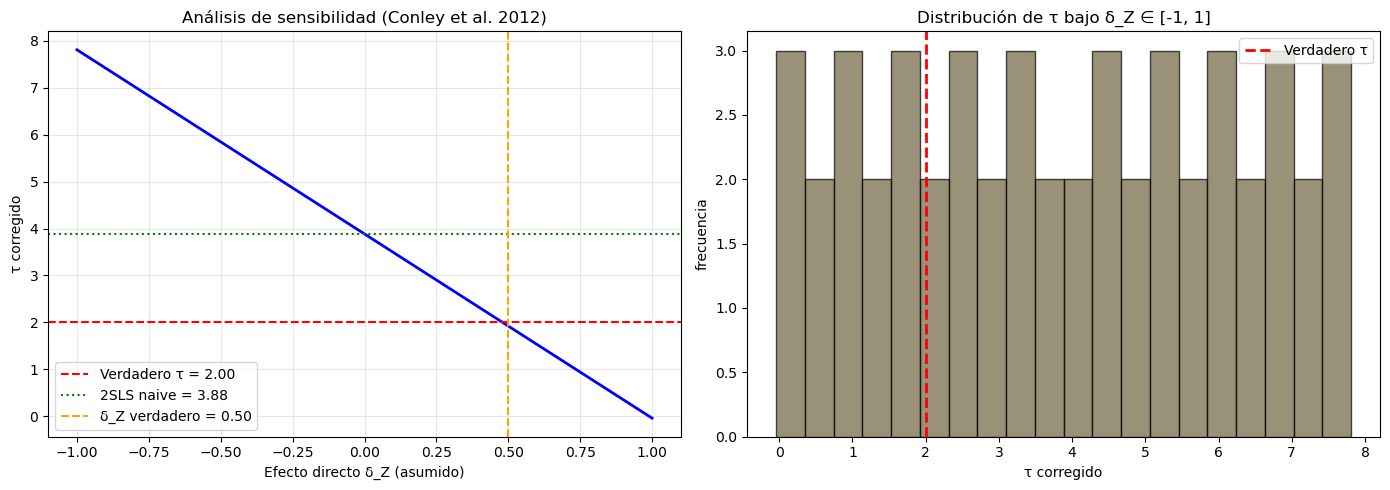


Interpretación:
  - Si δ_Z = 0 (exclusion válida): τ̂ = 3.8840
  - Si δ_Z = 0.50 (verdadero): τ̂_corregido = 1.9199
  → Sin conocer δ_Z, no podemos identificar τ exactamente.
    Solo podemos reportar bounds o análisis de sensibilidad.


In [4]:
# === 4. Análisis de sensibilidad: ¿qué efecto directo explicaría el sesgo? ===
# Si Z tiene efecto directo δ_Z sobre Y (violando exclusion):
# 2SLS estima: τ̂ = τ_true + δ_Z / π_1 (donde π_1 es primera etapa)
# Sensibilidad: variar δ_Z y ver cómo cambia τ̂

pi_1 = fs.params['z_instrument']  # primera etapa
delta_z_values = np.linspace(-1, 1, 50)
tau_corrected = tsls.params['d_hat'] - delta_z_values / pi_1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# τ corregido vs δ_Z asumido
axes[0].plot(delta_z_values, tau_corrected, 'b-', linewidth=2)
axes[0].axhline(truth.true_tau.mean(), color='red', linestyle='--', label=f'Verdadero τ = {truth.true_tau.mean():.2f}')
axes[0].axhline(tsls.params['d_hat'], color='green', linestyle=':', label=f'2SLS naive = {tsls.params["d_hat"]:.2f}')
axes[0].axvline(truth.direct_effect_z_truth.iloc[0], color='orange', linestyle='--', 
                label=f'δ_Z verdadero = {truth.direct_effect_z_truth.iloc[0]:.2f}')
axes[0].set_xlabel('Efecto directo δ_Z (asumido)')
axes[0].set_ylabel('τ corregido')
axes[0].set_title('Análisis de sensibilidad (Conley et al. 2012)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma: distribución de τ corregido para δ_Z ∈ [-1, 1]
axes[1].hist(tau_corrected, bins=20, color='#6e623f', alpha=0.7, edgecolor='black')
axes[1].axvline(truth.true_tau.mean(), color='red', linestyle='--', linewidth=2, label='Verdadero τ')
axes[1].set_xlabel('τ corregido'); axes[1].set_ylabel('frecuencia')
axes[1].set_title('Distribución de τ bajo δ_Z ∈ [-1, 1]')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nInterpretación:')
print(f'  - Si δ_Z = 0 (exclusion válida): τ̂ = {tsls.params["d_hat"]:.4f}')
print(f'  - Si δ_Z = {truth.direct_effect_z_truth.iloc[0]:.2f} (verdadero): τ̂_corregido = {tsls.params["d_hat"] - truth.direct_effect_z_truth.iloc[0]/pi_1:.4f}')
print(f'  → Sin conocer δ_Z, no podemos identificar τ exactamente.')
print(f'    Solo podemos reportar bounds o análisis de sensibilidad.')


> 💡 **Interpretación de la figura.** La figura traza el $\hat{\tau}$ corregido en función del efecto directo asumido $\delta_Z$: en $\delta_Z=0$ el estimador vale $3.8840$ (sesgado) y con el valor verdadero $\delta_Z=0.50$ cae a $1.9199$, muy cerca del $\tau=2.0$ real; el panel derecho muestra la distribución de $\tau$ bajo $\delta_Z\in[-1,1]$ (sección 4). El patrón visible —sensibilidad casi lineal al supuesto de exclusión— implica que sin conocer $\delta_Z$ solo cabe reportar bounds o análisis de sensibilidad, no un número puntual.


In [5]:
# === 5. Hoja de ruta: problemas abiertos y dirección futura ===
print(f'=== HOJA DE RUTA: IA Causal 2026-2030 ===')

problems = [
    ('1. Confounder latente', 
     'CEVAE/TARNet approximan pero no resuelven. Bounds (Manski) son anchos.',
     'Causal foundation models pre-entrenados en datos causales múltiples'),
    ('2. Validez de IV',
     'Sargan requiere sobreidentificación. Con 1 IV, no testeable.',
     'Conley bounds estándar en software; tests no paramétricos'),
    ('3. External validity',
     'LATE en contexto A puede no aplicar a contexto B.',
     'Transportabilidad formal (Pearl & Bareinboim 2014); meta-análisis causal'),
    ('4. Descubrimiento escalable',
     'PC es NP-hard; NOTEARS asume no linealidad suave.',
     'GPU acceleration; aprendizajede representaciones causales'),
    ('5. Inferencia en DL',
     'Bootstrap es costoso; falta teoría asintótica para NN.',
     'Conformal prediction causal; neural tangent kernel para inferencia'),
    ('6. LLM + causal',
     'Alucinan; reflejan sesgos web; no grounded.',
     'RAG + causal graphs; fine-tuning en datos causales sintéticos'),
    ('7. Causal fairness',
     'Requiere DAG (subjetivo); path-specific es complejo.',
     'Auditoría algorítmica estándar; regulatory frameworks'),
    ('8. Causal RL',
     'Confounding en datos históricos; ética de exploración.',
     'Causal bandits con safety constraints; human-in-the-loop'),
]

print(f'\n{"Problema":<25} {"Estado actual":<45} {"Dirección 2026-2030":<45}')
print(f'{"-"*120}')
for p, estado, direccion in problems:
    print(f'{p:<25} {estado[:43]:<45} {direccion[:43]:<45}')


=== HOJA DE RUTA: IA Causal 2026-2030 ===

Problema                  Estado actual                                 Dirección 2026-2030                          
------------------------------------------------------------------------------------------------------------------------
1. Confounder latente     CEVAE/TARNet approximan pero no resuelven.    Causal foundation models pre-entrenados en   
2. Validez de IV          Sargan requiere sobreidentificación. Con 1    Conley bounds estándar en software; tests n  
3. External validity      LATE en contexto A puede no aplicar a conte   Transportabilidad formal (Pearl & Bareinboi  
4. Descubrimiento escalable PC es NP-hard; NOTEARS asume no linealidad    GPU acceleration; aprendizajede representac  
5. Inferencia en DL       Bootstrap es costoso; falta teoría asintóti   Conformal prediction causal; neural tangent  
6. LLM + causal           Alucinan; reflejan sesgos web; no grounded.   RAG + causal graphs; fine-tuning en datos c  
7. Causa

> 💡 **Interpretación del resultado.** La hoja de ruta 2026-2030 (sección 5) enmarca los cuatro problemas abiertos que el curso deja planteados: confusores latentes, validez de IV, validez externa y descubrimiento escalable (con la advertencia de que PC es NP-hard y NOTEARS asume no linealidad). La lectura GCE es que estos frentes refinan los mismos principios ya vistos —identificación, transporte y geometría— más que introducir paradigmas nuevos.


In [6]:
# === 5b. Los 7 Pilares de la IA Causal (Pearl, 2019) — tabla ejecutable ===
# Réplica de la tabla `tab:pilares_pearl` de libro/capitulos/capitulo32.typ,
# como ejercicio ejecutable (no solo prosa): pilar, estrato de la escalera de
# Pearl, capacidad, herramienta desarrollada en el libro, capítulos, y si los
# LLMs de 2026 lo cubren nativamente.
pilares_pearl = pd.DataFrame([
    {'Pilar': '1. Predictibilidad', 'Estrato': 'Nivel 1 (Asoc.)', 'Capacidad': 'P(Y|X=x)',
     'Herramienta': 'ML supervisado, regresión', 'Caps': '1-6', 'LLMs_2026': 'Sí (nativo)'},
    {'Pilar': '2. Intervención', 'Estrato': 'Nivel 2 (Interv.)', 'Capacidad': 'P(Y|do(X=x))',
     'Herramienta': 'DAGs, do-cálculo, RCT', 'Caps': '7-12, 13-16', 'LLMs_2026': 'Parcial (CoT)'},
    {'Pilar': '3. Contrafactuales', 'Estrato': 'Nivel 3 (CF)', 'Capacidad': "P(Y_x' | X=x', Y=y')",
     'Herramienta': 'SCM, NCM, abducción', 'Caps': '13, 19, 29', 'LLMs_2026': 'No (sin MCE)'},
    {'Pilar': '4. Atribución', 'Estrato': 'Nivel 3 (CF)', 'Capacidad': 'PoC, PN, PS',
     'Herramienta': 'Efecto de camino, PSE', 'Caps': '19, 31', 'LLMs_2026': 'No'},
    {'Pilar': '5. Explicabilidad', 'Estrato': 'Nivel 2-3', 'Capacidad': 'Por qué Y ocurrió',
     'Herramienta': 'NDE/NIE, SHAP causal', 'Caps': '10, 31', 'LLMs_2026': 'Parcial'},
    {'Pilar': '6. Control', 'Estrato': 'Nivel 2-3', 'Capacidad': 'Política óptima',
     'Herramienta': 'RL causal, DTR, OPE', 'Caps': '26, 28', 'LLMs_2026': 'No'},
    {'Pilar': '7. Descubrimiento', 'Estrato': 'Meta-nivel', 'Capacidad': 'Aprender G desde datos',
     'Herramienta': 'PC, GES, LiNGAM, NOTEARS', 'Caps': '20', 'LLMs_2026': 'Emergente'},
])

print('=== Los 7 Pilares de la IA Causal (Pearl, 2019) — tab:pilares_pearl (Cap. 32 del libro) ===')
print(pilares_pearl.to_string(index=False))

# Validación de criterios: exactamente 7 pilares, y los LLMs de 2026 cubren
# nativamente solo el Pilar 1 (checklist Riguroso del Cap. 32, ítem 2).
assert len(pilares_pearl) == 7, 'Deben ser exactamente 7 pilares (Pearl 2019)'
cobertura_nativa = (pilares_pearl['LLMs_2026'] == 'Sí (nativo)').sum()
print(f'\nPilares cubiertos NATIVAMENTE por LLMs (2026): {cobertura_nativa} de 7')
assert cobertura_nativa == 1, 'Solo el Pilar 1 (Predictibilidad) debería estar cubierto nativamente'
print('→ Los LLMs de 2026 cubren nativamente solo el Pilar 1 (Nivel 1, asociación).')
print('  Los Pilares 3, 4 y 6 requieren Modelos Causales Estructurales (MCE) explícitos')
print('  — el problema abierto central de la IA causal (Cap. 32 del libro, ref. tab:pilares_pearl).')


=== Los 7 Pilares de la IA Causal (Pearl, 2019) — tab:pilares_pearl (Cap. 32 del libro) ===
             Pilar           Estrato              Capacidad               Herramienta        Caps     LLMs_2026
1. Predictibilidad   Nivel 1 (Asoc.)               P(Y|X=x) ML supervisado, regresión         1-6   Sí (nativo)
   2. Intervención Nivel 2 (Interv.)           P(Y|do(X=x))     DAGs, do-cálculo, RCT 7-12, 13-16 Parcial (CoT)
3. Contrafactuales      Nivel 3 (CF)   P(Y_x' | X=x', Y=y')       SCM, NCM, abducción  13, 19, 29  No (sin MCE)
     4. Atribución      Nivel 3 (CF)            PoC, PN, PS     Efecto de camino, PSE      19, 31            No
 5. Explicabilidad         Nivel 2-3      Por qué Y ocurrió      NDE/NIE, SHAP causal      10, 31       Parcial
        6. Control         Nivel 2-3        Política óptima       RL causal, DTR, OPE      26, 28            No
 7. Descubrimiento        Meta-nivel Aprender G desde datos  PC, GES, LiNGAM, NOTEARS          20     Emergente

Pilares cub

> 💡 **Interpretación del resultado.** La tabla de los 7 pilares de Pearl (2019) —réplica de `tab:pilares_pearl`— mapea cada capacidad causal a su estrato: predictibilidad (Nivel 1), intervención (Nivel 2), contrafactuales y atribución (Nivel 3) (sección 5b). La columna LLMs_2026 resume el estado de la frontera: los LLM son nativos en predicción, parciales en intervención y no alcanzan el razonamiento contrafactual sin un modelo causal explícito (MCE).


In [7]:
# === 6. Síntesis final del curso ===
print(f'=== SÍNTESIS: 32 capítulos en una página ===')

print(f'''
┌──────────────────────────────────────────────────────────────────┐
│  BLOQUE I — FUNDAMENTACIÓN (Caps. 1-12)                          │
│  Nivel 1 GCE: Localización (ATE, ATT, LATE)                      │
│  Métodos: RCT, Matching, IPW, IV, RDD, DiD, SCM, Mediación      │
│  Lección: CIA es el supuesto crux; reportar múltiples métodos    │
├──────────────────────────────────────────────────────────────────┤
│  BLOQUE II — FORMALIZACIÓN (Caps. 13-19)                         │
│  Nivel 2 GCE: Forma (SCM, DAGs, do-calculus)                     │
│  Métodos: SCM, DAGs, Backdoor, Frontdoor, Do-Calculus, CF        │
│  Lección: el DAG guía la elección de controles                   │
├──────────────────────────────────────────────────────────────────┤
│  BLOQUE III — DESCUBRIMIENTO Y HETEROGENEIDAD (Caps. 20-27)      │
│  Precondición + Nivel 3: ML Causal                               │
│  Métodos: PC, Meta-Learners, DML, Causal Forests, OPE, CFR       │
│  Lección: ML no resuelve confusor oculto; DML es estándar        │
├──────────────────────────────────────────────────────────────────┤
│  BLOQUE IV — CAUSAL AI (Caps. 28-32)                             │
│  Frontera tecnológica                                            │
│  Métodos: RL causal, Deep Causal + LLMs, Agentes, Equidad        │
│  Lección: agentes automatizan juicio metodológico                │
└──────────────────────────────────────────────────────────────────┘
''')

print(f'PRINCIPIOS TRANSVERSALES:')
print(f'1. La causalidad requiere supuestos (no hay almuerzo gratis)')
print(f'2. Validación con placebos y sensibilidad SIEMPRE')
print(f'3. Múltiples métodos > un solo método')
print(f'4. Transparencia sobre supuestos > elegancia matemática')
print(f'5. Validez externa importa tanto como identificación')

print(f'\nBIBLIOGRAFÍA FUNDAMENTAL:')
refs = [
    'Pearl, J. (2009). Causality. Cambridge University Press.',
    'Hernán, M. & Robins, J. (2020). Causal Inference: What If.',
    'Angrist, J. & Pischke, J.S. (2009). Mostly Harmless Econometrics.',
    'Cunningham, S. (2021). Causal Inference: The Mixtape. Yale UP.',
    'Imbens, G. & Rubin, D. (2015). Causal Inference for Statistics.',
    'Chernozhukov, V. et al. (2018). Double/debiased ML. Econometrica.',
    'Athey, S. & Imbens, G. (2016). Recursive partitioning for heterogeneous effects. PNAS.',
    'Künzel, S. et al. (2019). Metalearners for estimating HTE. PNAS.',
    'Pearl, J. & Mackenzie, D. (2018). The Book of Why. Basic Books.',
    'Kusner, M. et al. (2017). Counterfactual Fairness. NeurIPS.',
]
for r in refs:
    print(f'  - {r}')

print(f'\n=== FIN DEL CURSO ===')
print(f'Has completado 32 capítulos de Inferencia Causal Aplicada con Python.')
print(f'Los 32 notebooks están listos para uso docente y autoaprendizaje.')
print(f'\nPróximos pasos recomendados:')
print(f'1. Reproducir los notebooks con tus propios datos')
print(f'2. Explorar bibliografía especializada por tema')
print(f'3. Contribuir a open-source: econml, causal-learn, DoubleML')
print(f'4. Aplicar a problemas reales en política pública / investigación')
print(f'\n¡Felicidades por completar DES504 — UNI 2026!')


=== SÍNTESIS: 32 capítulos en una página ===

┌──────────────────────────────────────────────────────────────────┐
│  BLOQUE I — FUNDAMENTACIÓN (Caps. 1-12)                          │
│  Nivel 1 GCE: Localización (ATE, ATT, LATE)                      │
│  Métodos: RCT, Matching, IPW, IV, RDD, DiD, SCM, Mediación      │
│  Lección: CIA es el supuesto crux; reportar múltiples métodos    │
├──────────────────────────────────────────────────────────────────┤
│  BLOQUE II — FORMALIZACIÓN (Caps. 13-19)                         │
│  Nivel 2 GCE: Forma (SCM, DAGs, do-calculus)                     │
│  Métodos: SCM, DAGs, Backdoor, Frontdoor, Do-Calculus, CF        │
│  Lección: el DAG guía la elección de controles                   │
├──────────────────────────────────────────────────────────────────┤
│  BLOQUE III — DESCUBRIMIENTO Y HETEROGENEIDAD (Caps. 20-27)      │
│  Precondición + Nivel 3: ML Causal                               │
│  Métodos: PC, Meta-Learners, DML, Causal Forests, OPE, C

> 💡 **Interpretación del resultado.** La síntesis comprime los 32 capítulos en los cuatro bloques del curso con su lección central: la CIA como supuesto crux en el Bloque I, el DAG como guía de controles en el II, descubrimiento y ML causal en el III y la frontera de IA causal en el IV (sección 6). El valor pedagógico del output es recordar que todos los métodos comparten una estructura común —identificar, estimar y auditar— justo antes del cierre de la cadena maestra en la sección 7.


In [8]:
# === 7. Cierre de la cadena maestra GCE: experimento canónico del Cap. 1 ===
# Para cerrar el curso, replicamos exactamente el experimento canónico (semilla 42,
# n=5000) que abrió el Cap. 1 — la Paradoja del Efecto Cero — cuya fuente de verdad
# es gce/artifacts/ejemplo_paradoja_canonico.py. Todo lo visto en los 32 capítulos,
# desde la diferencia de medias hasta los agentes ASCSD (Cap. 30) y la equidad
# contrafactual (Cap. 31), son instancias de esta misma cadena
# |tau_ATE| <= W1 <= W^{G,1}.
from scipy.stats import wasserstein_distance
from scipy.special import rel_entr

np.random.seed(42)
n_cap1 = 5000

# Control: N(120, 12). Tratamiento: mezcla 105/135 con la MISMA media (120)
Y0_cap1 = np.random.normal(120, 12, n_cap1)
Y1_cap1 = np.concatenate([
    np.random.normal(105, 8, n_cap1 // 2),   # respondedores
    np.random.normal(135, 10, n_cap1 // 2),  # no respondedores
])

tau_ate_cap1 = np.mean(Y1_cap1) - np.mean(Y0_cap1)

bins_cap1 = np.linspace(60, 180, 61)
p0_cap1, _ = np.histogram(Y0_cap1, bins=bins_cap1, density=True)
p1_cap1, _ = np.histogram(Y1_cap1, bins=bins_cap1, density=True)
kl_cap1 = np.sum(rel_entr(p1_cap1 + 1e-10, p0_cap1 + 1e-10)) * (bins_cap1[1] - bins_cap1[0])

w1_cap1 = wasserstein_distance(Y0_cap1, Y1_cap1)
cota_dual_cap1 = np.mean(np.abs(Y1_cap1 - 120)) - np.mean(np.abs(Y0_cap1 - 120))

print('=== CIERRE DEL CURSO: experimento canónico del Cap. 1 (semilla 42, n=5000) ===')
print(f'Nivel 1 ATE      : {tau_ate_cap1:.3f} mmHg  <- ciego a la reconfiguración')
print(f'Nivel 2 D_KL     : {kl_cap1:.3f} nats   <- detecta cambio de forma')
print(f'Nivel 3 W1       : {w1_cap1:.3f} mmHg  <- costo de transporte')
print(f'Cota dual        : {cota_dual_cap1:.3f} <= W1 = {w1_cap1:.3f}')

assert abs(tau_ate_cap1) <= w1_cap1 + 1e-6, 'Violación |ATE| <= W1'
assert cota_dual_cap1 <= w1_cap1 + 1e-6, 'Violación dualidad Kantorovich-Rubinstein'

print(f'\n✓ Cadena maestra cerrada: |tau_ATE| = {abs(tau_ate_cap1):.3f} <= W1 = {w1_cap1:.3f}')
print('  Este es el mismo assert que abrió el curso en el Cap. 1. Matching, IPW,')
print('  IV, RDD, DiD, SCM (Bloque I, N1); DAGs y do-cálculo (Bloque II, N2);')
print('  descubrimiento y ML causal (Bloque III); RL causal, deep causal, agentes')
print('  ASCSD y equidad contrafactual (Bloque IV) — todos son instancias de la')
print('  misma desigualdad |tau_ATE| <= W1 <= W^{G,1}.')
print('\n=== FIN DE LA CADENA MAESTRA GCE — FIN DEL CURSO DES504 ===')


=== CIERRE DEL CURSO: experimento canónico del Cap. 1 (semilla 42, n=5000) ===
Nivel 1 ATE      : -0.137 mmHg  <- ciego a la reconfiguración
Nivel 2 D_KL     : 0.364 nats   <- detecta cambio de forma
Nivel 3 W1       : 6.050 mmHg  <- costo de transporte
Cota dual        : 6.029 <= W1 = 6.050

✓ Cadena maestra cerrada: |tau_ATE| = 0.137 <= W1 = 6.050
  Este es el mismo assert que abrió el curso en el Cap. 1. Matching, IPW,
  IV, RDD, DiD, SCM (Bloque I, N1); DAGs y do-cálculo (Bloque II, N2);
  descubrimiento y ML causal (Bloque III); RL causal, deep causal, agentes
  ASCSD y equidad contrafactual (Bloque IV) — todos son instancias de la
  misma desigualdad |tau_ATE| <= W1 <= W^{G,1}.

=== FIN DE LA CADENA MAESTRA GCE — FIN DEL CURSO DES504 ===


> 💡 **Interpretación del resultado.** El curso cierra replicando el experimento canónico del Cap. 1 (semilla 42, $n=5000$): $|\tau_{\mathrm{ATE}}|=0.137$ mmHg $\le W_1=6.050$ mmHg, con cota dual $6.029 \le W_1$ —el mismo assert que abrió el curso (sección 7). El ATE casi nulo es ciego a la reconfiguración de la distribución que la KL ($0.364$ nats) detecta, mientras $W_1$, **cota superior** de $|\tau_{\mathrm{ATE}}|$, cuantifica el costo de transporte: la paradoja del efecto cero se cierra mostrando que todos los métodos del curso son instancias de $|\tau_{\mathrm{ATE}}| \le W_1 \le W^{G,1}$.


## 5. Interpretación Final

Este capítulo cierra el curso señalando que la inferencia causal es un campo **vivo y en evolución**:

1. **No hay método universal.** Cada problema causal requiere elegir entre RCT, IV, RDD, DiD, SCM, DML, etc. según el contexto y los supuestos plausibles. Los agentes causales (Cap. 30) intentan automatizar esta elección, pero el juicio humano sigue siendo esencial.

2. **Confounder latente es el problema fundamental.** Todos los métodos observacionales (Bloques I-IV) fallan cuando hay $U$ no observable. CEVAE y variantes approximan pero no resuelven. La honestidad sobre esta limitación es clave.

3. **La IA causal es la frontera.** Deep learning + LLMs abren nuevas posibilidades (representaciones ricas, razonamiento en lenguaje natural) pero también riesgos (cajas negras, alucinaciones). La integración con métodos clásicos (IPW, DML) es el camino más prometedor.

4. **Equidad y regulación importan.** Los algoritmos causales pueden perpetuar o mitigar sesgos. La equidad contrafactual ofrece un marco más sutil que las métricas observacionales.

5. **Supuestos > Elegancia.** Un análisis causal creíble es transparente sobre sus supuestos, valida con placebos y sensibilidad, y reporta múltiples especificaciones. La elegancia matemática no sustituye la credibilidad.

**Mensaje final para el estudiante:**
La inferencia causal es tanto un arte como una ciencia. Los métodos se aprenden, pero el juicio sobre cuándo aplicarlos se desarrolla con práctica. Los 32 notebooks de este curso son un punto de partida; la maestría viene de aplicarlos a problemas reales, cometer errores, y aprender de la literatura en constante evolución.

**¡Felicidades por completar DES504 — Inferencia Causal Aplicada con Python!**

## 6. Ejercicios Finales Integradores

1. **Proyecto integrador:** elige un problema causal real (política pública, salud, educación) y aplica el pipeline completo: dibujar DAG, elegir método, estimar, validar, interpretar.

2. **Replicación:** replica un paper publicado (ej. Card 1995, Abadie 2010, Chernozhukov 2018) usando los notebooks del curso.

3. **Contribución open-source:** identifica un issue en `econml`, `causal-learn` o `DoubleML` y contribuye con un fix o documentación.

4. **Ensayo crítico:** escribe 2000 palabras sobre "Limitaciones de la IA Causal en 2026" usando los problemas abiertos de este capítulo.

5. **Caso de estudio peruano:** aplica los métodos a un problema de política pública peruana (Pensión 65, Beca 18, Juntos) y discute validez externa.

---

*Notebook generado para DES504 — UNI 2026. Bloque IV, Capítulo 32 de 32. Cierra el curso.*



## 📋 Resumen del Capítulo 32

**Método clave:** Hoja de Ruta IA Causal

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 32
- ✅ Validación con dataset `syn_iv_invalid_exclusion` (tipo: sintético con ground truth)
- ✅ Sec. 5b: tabla ejecutable de los 7 Pilares de la IA Causal (Pearl, 2019), réplica de `tab:pilares_pearl`
- ✅ Sec. 7: cierre de la cadena maestra con el experimento canónico del Cap. 1 (semilla 42), con `assert`
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo es la **Síntesis GCE** del curso completo: recapitula Nivel 1 (Bloque I), Nivel 2 (Bloque II) y Nivel 3 + frontera (Bloques III-IV).
- La Sec. 7 cierra explícitamente la cadena maestra |ATE| ≤ W1 con los números canónicos del Cap. 1 (ATE≈-0.137, W1≈6.050, seed 42), no como una etiqueta genérica de "Nivel 3 Geometría" sin cómputo de respaldo.
- Pipeline unificado (Cap. 12): los 32 capítulos son variaciones sobre la misma desigualdad |tau_ATE| ≤ W1 ≤ W^{G,1}.

**Próximo capítulo:** Fin del curso

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y corregido (bug sistémico de cabecera/pie GCE + tabla 7 pilares + cierre canónico) — 2026-07-30*
